# Generate ROC AUC plot demonstrating improvement in `performance` after QC

This code is derived from the `cellpainting_predicts_cardiac_fibrosis` repository.

In [1]:
import pathlib
import sys

import joblib
import numpy as np
import pandas as pd
from joblib import load
from plotnine import (
    aes,
    element_line,
    element_text,
    geom_histogram,
    geom_vline,
    ggplot,
    labs,
    scale_fill_manual,
    theme,
    theme_bw,
)
from plotnine.options import set_option
from scipy.stats import ttest_ind
from sklearn.metrics import roc_auc_score

sys.path.append("./")
from figure3_utils import bootstrap_roc_auc, get_X_y_data

In [2]:
figure_path = pathlib.Path("./figures")
# make directory if it doesn't already exist
figure_path.mkdir(exist_ok=True)

## Load in label encoder

In [3]:
# load in label encoder
le = load(
    pathlib.Path(
        "/media/18tbdrive/1.Github_Repositories/cellpainting_predicts_cardiac_fibrosis/5.machine_learning/0.train_logistic_regression/encoder_results/label_encoder_log_reg_fs_plate_4.joblib"
    )
)

/home/jenna/.cache/pypoetry/virtualenvs/cosmicqc-vNopUmqk-py3.11/lib/python3.11/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator LabelEncoder from version 1.3.2 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations


## Load in no-QC model and dataset

In [4]:
# Load the trained model
no_QC_model = joblib.load(
    pathlib.Path(
        "/media/18tbdrive/1.Github_Repositories/cellpainting_predicts_cardiac_fibrosis/5.machine_learning/0.train_logistic_regression/models/no_QC_models/log_reg_fs_plate_4_final_downsample_no_QC.joblib"
    )
)

# Load the feature-selected QC plate 4 (ensure it includes both features and labels)
plate_4_no_QC = pd.read_parquet(
    pathlib.Path(
        "/media/18tbdrive/1.Github_Repositories/cellpainting_predicts_cardiac_fibrosis/3.process_cfret_features/data/single_cell_profiles/localhost231120090001_sc_feature_selected_no_QC.parquet"
    )
)

# Filter the test_data to only include rows where:
# - Metadata_heart_number == 7 and Metadata_treatment == "DMSO"
# - OR Metadata_heart_number == 29
healthy_heart_number = 7
failing_heart_number = 29
holdout_no_QC_data = plate_4_no_QC[
    (
        (plate_4_no_QC["Metadata_heart_number"] == healthy_heart_number)
        & (plate_4_no_QC["Metadata_treatment"] == "DMSO")
    )
    | (plate_4_no_QC["Metadata_heart_number"] == failing_heart_number)
]

# Load in X and y data from dataset
X, y = get_X_y_data(df=holdout_no_QC_data, label="Metadata_cell_type")

# Assign y classes to correct binary using label encoder results
y_binary_no_QC = le.transform(y)

# Predict probabilities for the positive class
y_probs_modelNoQC = no_QC_model.predict_proba(X)[:, 1]

/home/jenna/.cache/pypoetry/virtualenvs/cosmicqc-vNopUmqk-py3.11/lib/python3.11/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator LogisticRegression from version 1.3.2 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations


## Load in QC model and dataset

In [5]:
# Load the trained model
QC_model = joblib.load(
    pathlib.Path(
        "/media/18tbdrive/1.Github_Repositories/cellpainting_predicts_cardiac_fibrosis/5.machine_learning/0.train_logistic_regression/models/log_reg_fs_plate_4_final_downsample.joblib"
    )
)

# Load the feature-selected QC plate 4 (ensure it includes both features and labels)
plate_4_QC = pd.read_parquet(
    pathlib.Path(
        "/media/18tbdrive/1.Github_Repositories/cellpainting_predicts_cardiac_fibrosis/3.process_cfret_features/data/single_cell_profiles/localhost231120090001_sc_feature_selected.parquet"
    )
)

# Filter the test_data to only include rows where:
# - Metadata_heart_number == 7 and Metadata_treatment == "DMSO"
# - OR Metadata_heart_number == 29
holdout_QC_data = plate_4_QC[
    (
        (plate_4_QC["Metadata_heart_number"] == healthy_heart_number)
        & (plate_4_QC["Metadata_treatment"] == "DMSO")
    )
    | (plate_4_QC["Metadata_heart_number"] == failing_heart_number)
]

# Load in X and y data from dataset
X, y = get_X_y_data(df=holdout_QC_data, label="Metadata_cell_type")

# Assign y classes to correct binary using label encoder results
y_binary_QC = le.transform(y)

# Predict probabilities for the positive class
y_probs_modelQC = QC_model.predict_proba(X)[:, 1]

/home/jenna/.cache/pypoetry/virtualenvs/cosmicqc-vNopUmqk-py3.11/lib/python3.11/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator LogisticRegression from version 1.3.2 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations


## Calculate ROC AUC score by applying the model to their respective dataset

e.g., QC model applyied on QC heldout wells dataset and vice versa.

In [6]:
# Calculate ROC AUC
aucNoQC = roc_auc_score(y_binary_no_QC, y_probs_modelNoQC)
aucQC = roc_auc_score(y_binary_QC, y_probs_modelQC)

print(f"AUC Model 1: {aucNoQC}")
print(f"AUC Model 2: {aucQC}")

AUC Model 1: 0.9053365172047568
AUC Model 2: 0.9288569897636957


## Apply bootstrapping method to evaluate performance between models

We apply this method to 20% of the datasets, without replacement, and 1000 iterations for the bootstrapping method.
T-Test is used to see if the distributions are significantly different.

In [7]:
# No QC model
scores_model1 = bootstrap_roc_auc(y_binary_no_QC, y_probs_modelNoQC)

# QC model
scores_model2 = bootstrap_roc_auc(y_binary_QC, y_probs_modelQC)

# Compare distributions
t_stat, p_value = ttest_ind(scores_model1, scores_model2)
print(f"T-statistic: {t_stat}, P-value: {p_value}")

T-statistic: -53.021426602971395, P-value: 0.0


In [8]:
print(f"Mean ROC AUC for Model No-QC: {np.mean(scores_model1)}")
print(f"Mean ROC AUC for Model QC: {np.mean(scores_model2)}")

Mean ROC AUC for Model No-QC: 0.9049444191457815
Mean ROC AUC for Model QC: 0.9286563637756533


/home/jenna/.cache/pypoetry/virtualenvs/cosmicqc-vNopUmqk-py3.11/lib/python3.11/site-packages/plotnine/ggplot.py:606: PlotnineWarning: Saving 8 x 7 in image.
/home/jenna/.cache/pypoetry/virtualenvs/cosmicqc-vNopUmqk-py3.11/lib/python3.11/site-packages/plotnine/ggplot.py:607: PlotnineWarning: Filename: figures/bootstrap_ROC_AUC_QC_versus_no_QC.png


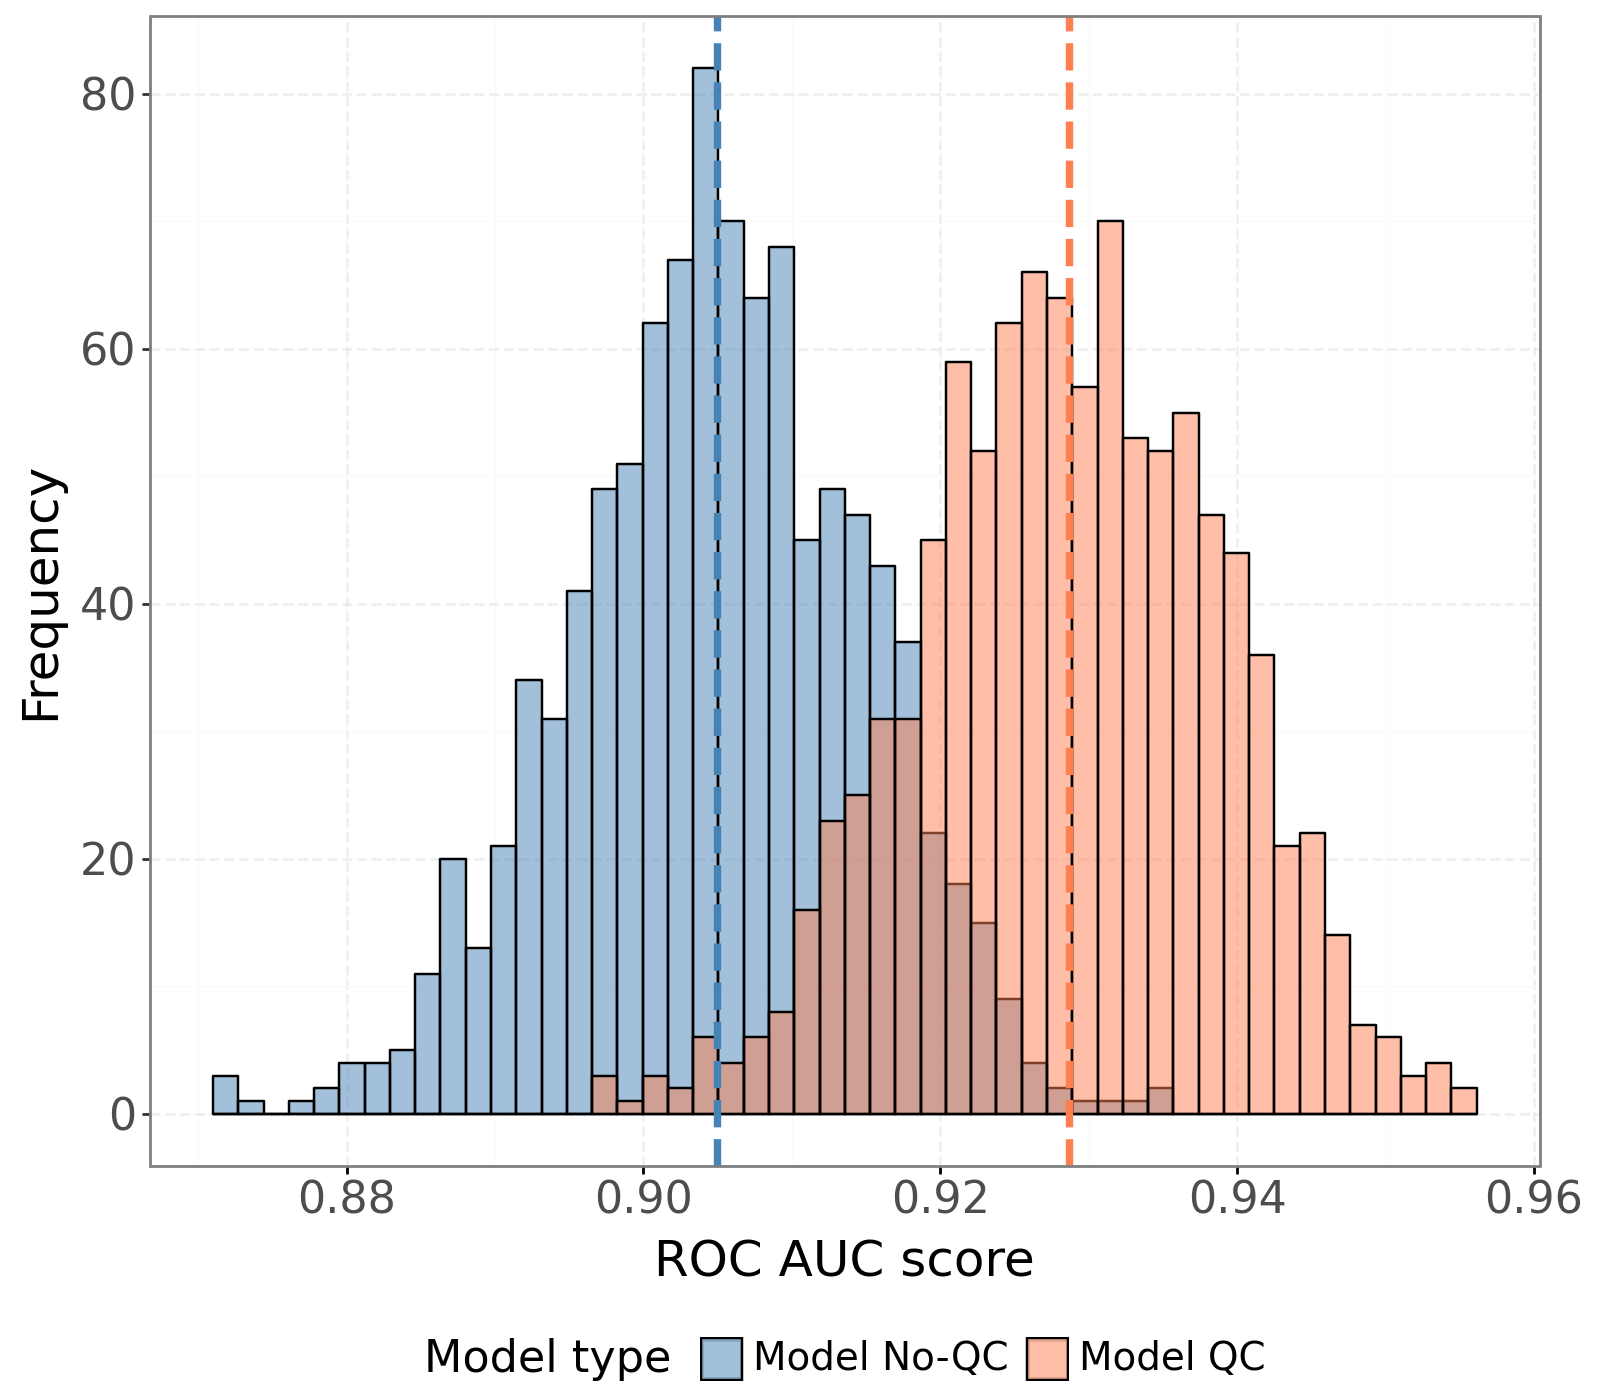

In [9]:
# Prepare the data
df_model1 = pd.DataFrame({"score": scores_model1, "model": "Model No-QC"})
df_model2 = pd.DataFrame({"score": scores_model2, "model": "Model QC"})
df_all = pd.concat([df_model1, df_model2])

# Set the figure size
height = 7
width = 8
set_option("figure_size", (width, height))

# Create the plot
p = (
    ggplot(df_all, aes(x="score", fill="model"))
    + geom_histogram(bins=50, alpha=0.5, position="identity", color="black")
    + geom_vline(
        xintercept=[np.mean(scores_model1), np.mean(scores_model2)],
        linetype="dashed",
        size=1.5,
        color=["steelblue", "coral"],
    )
    + scale_fill_manual(values={"Model No-QC": "steelblue", "Model QC": "coral"})
    + labs(
        x="ROC AUC score",
        y="Frequency",
        fill="Model type",
    )
    + theme_bw()
    + theme(
        legend_position="bottom",
        legend_title=element_text(size=16),
        legend_text=element_text(size=14),
        axis_title=element_text(size=18),
        axis_text=element_text(size=16),
        panel_grid_major=element_line(linetype="--", alpha=0.6),
    )
)

# Save and show
p.save(f"{figure_path}/bootstrap_ROC_AUC_QC_versus_no_QC.png", dpi=600)
p.show()